# Cell 1 — Markdown
# Step 6: Baseline Model Development

## Objective

The objective of this step is to build baseline machine learning models that predict whether a customer will respond to a commercial campaign.

The target variable is:

**y = customer campaign response**

In the UCI Bank Marketing dataset:

- `yes` means the customer subscribed to the term deposit
- `no` means the customer did not subscribe

This step compares three baseline models:

| Model | Purpose |
|---|---|
| Logistic Regression | Interpretable baseline model |
| Random Forest | Nonlinear model that captures complex patterns |
| Gradient Boosting | Strong predictive model for campaign response prediction |

The final recommended model will be selected based on predictive performance and business usefulness.

In [148]:
# Cell 2 — Import Libraries
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [149]:
# Cell 3 — Locate Project Folder and Load Data
# Find project root folder
# Step 6: Locate Project Folder and Load Data

from pathlib import Path
import pandas as pd

# Current notebook working directory
current_dir = Path.cwd()

print("Current working directory:")
print(current_dir)

# Try possible dataset locations
possible_paths = [
    current_dir / "data" / "raw" / "bank-additional-full.csv",
    current_dir.parent / "data" / "raw" / "bank-additional-full.csv",
    current_dir.parent.parent / "data" / "raw" / "bank-additional-full.csv"
]

data_path = None

for path in possible_paths:
    print("Checking:", path)
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find bank-additional-full.csv. "
        "Make sure it is located in data/raw/ inside the main project folder."
    )

print("Dataset found at:")
print(data_path)

# Load dataset
df = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Current working directory:
c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\notebooks
Checking: c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\notebooks\data\raw\bank-additional-full.csv
Checking: c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\data\raw\bank-additional-full.csv
Dataset found at:
c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\data\raw\bank-additional-full.csv
Dataset loaded successfully.
Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [150]:
# Cell 4 — Prepare Target Variable
# Check target values
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True) * 100)

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [151]:
# Cell 4 — Prepare Target Variable
# Convert target variable to binary format
# yes = 1 means customer responded
# no = 0 means customer did not respond

df["target"] = df["y"].map({"yes": 1, "no": 0})

# Drop original target column
df_model = df.drop(columns=["y"])

df_model.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [152]:
# Cell 5 — Define Features and Target
X = df_model.drop(columns=["target"])
y = df_model["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (41188, 20)
Target shape: (41188,)


In [153]:
# Cell 6 — Identify Numerical and Categorical Variables
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [154]:
# Cell 7 — Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining response rate:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest response rate:")
print(y_test.value_counts(normalize=True) * 100)


Training set shape: (32950, 20)
Test set shape: (8238, 20)

Training response rate:
target
0    88.734446
1    11.265554
Name: proportion, dtype: float64

Test response rate:
target
0    88.73513
1    11.26487
Name: proportion, dtype: float64


In [155]:
# Cell 8 — Build Preprocessing Pipeline
# Version-compatible OneHotEncoder
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder)
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [156]:
# Cell 9 — Define Baseline Models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.10,
        max_depth=3,
        random_state=42
    )
}

models

{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                        n_estimators=300, n_jobs=-1, random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42)}

In [157]:
# Cell 10 — Train and Evaluate Models
results = []

trained_models = {}

for model_name, model in models.items():
    print(f"Training model: {model_name}")
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
        "PR AUC": average_precision_score(y_test, y_prob)
    }
    
    results.append(metrics)
    trained_models[model_name] = pipeline

print("Model training completed.")

Training model: Logistic Regression
Training model: Random Forest
Training model: Gradient Boosting
Model training completed.


In [158]:
# Cell 11 — Compare Model Results
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["ROC AUC", "PR AUC"],
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
2,Gradient Boosting,0.921704,0.695712,0.542026,0.609328,0.953481,0.691556
1,Random Forest,0.889172,0.504559,0.894397,0.645161,0.952949,0.692567
0,Logistic Regression,0.865137,0.451200,0.911638,0.603639,0.943838,0.622248


In [159]:
# Cell 12 — Save Model Comparison Results
reports_path = PROJECT_ROOT / "reports"
reports_path.mkdir(exist_ok=True)

results_file = reports_path / "baseline_model_results.csv"

results_df.to_csv(results_file, index=False)

print(f"Baseline model results saved to: {results_file}")

Baseline model results saved to: c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\notebooks\reports\baseline_model_results.csv


In [160]:
# Cell 13 — Select Best Model
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best baseline model:")
print(best_model_name)

results_df.iloc[0]

Best baseline model:
Gradient Boosting


Model        Gradient Boosting
Accuracy              0.921704
Precision             0.695712
Recall                0.542026
F1 Score              0.609328
ROC AUC               0.953481
PR AUC                0.691556
Name: 2, dtype: object

In [161]:
# Cell 14 — Detailed Evaluation of Best Model
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred_best))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      7310
           1       0.70      0.54      0.61       928

    accuracy                           0.92      8238
   macro avg       0.82      0.76      0.78      8238
weighted avg       0.92      0.92      0.92      8238

Confusion Matrix:
[[7090  220]
 [ 425  503]]


#Cell 15 — Markdown Interpretation
## Baseline Model Results Summary

Three baseline models were trained and evaluated:

1. Logistic Regression
2. Random Forest
3. Gradient Boosting

Because the campaign-response problem is imbalanced, accuracy alone is not enough to evaluate model quality. The most important metrics are:

- **ROC AUC**, because it measures the model's ability to rank responders above non-responders
- **PR AUC**, because it is useful when the positive response class is relatively small
- **Recall**, because the business wants to identify as many likely responders as possible
- **Precision**, because outreach resources should not be wasted on customers unlikely to respond

The best baseline model should be selected based on ranking ability and commercial usefulness, not only raw accuracy.

For this project, the recommended final model candidate is the model with the strongest ROC AUC and PR AUC performance. In most campaign-response problems, either **Gradient Boosting** or **Random Forest** is expected to perform better than Logistic Regression because these models can capture nonlinear customer behavior patterns.

In [162]:
# Cell 16 — Save Customer-Level Prediction Scores
scored_customers = X_test.copy()

scored_customers["actual_response"] = y_test.values
scored_customers["predicted_response_probability"] = y_prob_best
scored_customers["predicted_response"] = y_pred_best

scored_customers = scored_customers.sort_values(
    by="predicted_response_probability",
    ascending=False
)

processed_path = PROJECT_ROOT / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)

scores_file = processed_path / "baseline_customer_response_scores.csv"

scored_customers.to_csv(scores_file, index=False)

print(f"Customer response scores saved to: {scores_file}")

scored_customers.head(10)

Customer response scores saved to: c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\notebooks\data\processed\baseline_customer_response_scores.csv


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,actual_response,predicted_response_probability,predicted_response
39655,92,retired,married,unknown,no,yes,no,cellular,may,thu,...,2,success,-1.8,93.876,-40.0,0.683,5008.7,0,0.933989,1
39498,80,retired,divorced,basic.4y,no,yes,yes,cellular,apr,thu,...,2,success,-1.8,93.749,-34.6,0.644,5008.7,1,0.924175,1
40078,72,retired,married,basic.4y,no,no,yes,cellular,jul,fri,...,1,success,-1.7,94.215,-40.3,0.822,4991.6,1,0.918346,1
40450,92,retired,married,unknown,no,no,yes,cellular,aug,tue,...,1,success,-1.7,94.027,-38.3,0.904,4991.6,1,0.918231,1
39993,27,unknown,single,university.degree,no,yes,no,cellular,jun,wed,...,2,success,-1.7,94.055,-39.8,0.767,4991.6,1,0.917278,1
29052,19,student,single,unknown,no,yes,no,telephone,apr,fri,...,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0.913175,1
39153,21,student,single,basic.9y,no,no,no,cellular,mar,wed,...,1,success,-1.8,93.369,-34.8,0.655,5008.7,1,0.911803,1
39680,52,management,married,university.degree,no,yes,no,cellular,may,fri,...,3,success,-1.8,93.876,-40.0,0.684,5008.7,1,0.910231,1
39607,52,admin.,married,university.degree,no,no,no,cellular,may,thu,...,2,success,-1.8,93.876,-40.0,0.677,5008.7,1,0.910172,1
40713,30,technician,single,professional.course,no,no,no,cellular,sep,tue,...,1,success,-1.1,94.199,-37.5,0.877,4963.6,0,0.907785,1


# Step 7: Evaluate Model Performance

This step evaluates the trained machine learning models using both standard classification metrics and business-focused commercial analytics metrics.

Standard machine learning metrics include ROC-AUC, accuracy, precision, recall, F1 score, and the confusion matrix.

Commercial analytics metrics include top-decile lift, precision at top 10%, precision at top 20%, cumulative gain, and response rate by propensity group.

In [163]:
#Cell 1: Import evaluation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Create output folders if they do not already exist
Path("reports").mkdir(exist_ok=True)
Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)

In [164]:
# Step 6: Build Baseline Models

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Confirm dataset is loaded
print("Dataset shape:", df.shape)

# Create target variable
y = df["y"].map({"yes": 1, "no": 0})

# Create feature matrix
X = df.drop(columns=["y"])

# Remove duration to avoid data leakage
# duration is only known after the call, so it should not be used for pre-campaign prediction
if "duration" in X.columns:
    X = X.drop(columns=["duration"])

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Encoder compatibility for different scikit-learn versions
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Preprocessing for Logistic Regression
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", one_hot_encoder, categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

# Preprocessing for tree-based models
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", one_hot_encoder, categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

# Model 1: Logistic Regression
logistic_regression_model = Pipeline(steps=[
    ("preprocessor", logistic_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Model 2: Random Forest
random_forest_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Model 3: Gradient Boosting
gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

# Train all models
logistic_regression_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)
gradient_boosting_model.fit(X_train, y_train)

print("All baseline models trained successfully.")
print("Models created:")
print("- logistic_regression_model")
print("- random_forest_model")
print("- gradient_boosting_model")

Dataset shape: (41188, 22)
Number of categorical features: 10
Number of numerical features: 10
All baseline models trained successfully.
Models created:
- logistic_regression_model
- random_forest_model
- gradient_boosting_model


In [165]:
# Cell 2: Collect trained models
# Collect trained models from Step 6

models = {}

possible_model_names = {
    "Logistic Regression": ["logistic_model", "log_reg_model", "logistic_regression_model"],
    "Random Forest": ["random_forest_model", "rf_model"],
    "Gradient Boosting": ["gradient_boosting_model", "gb_model", "gb_clf"]
}

for display_name, variable_names in possible_model_names.items():
    for variable_name in variable_names:
        if variable_name in globals():
            models[display_name] = globals()[variable_name]
            break

if len(models) == 0:
    raise ValueError(
        "No trained models were found. Check the model variable names from Step 6."
    )

print("Models available for evaluation:")
for model_name in models.keys():
    print("-", model_name)


Models available for evaluation:
- Logistic Regression
- Random Forest
- Gradient Boosting


In [166]:
# Cell 3: Evaluate models, rank by ROC AUC, and select final model

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Evaluate all trained models collected in the models dictionary
evaluation_results = []

for model_name, model in models.items():
    
    # Predict class labels
    y_pred = model.predict(X_test)
    
    # Predict probability for the positive class
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Store evaluation metrics
    evaluation_results.append({
        "Model": model_name,
        "ROC_AUC": roc_auc_score(y_test, y_proba),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1_Score": f1_score(y_test, y_pred),
        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })

# Convert results to DataFrame
evaluation_df = pd.DataFrame(evaluation_results)

# Sort models from best to worst using ROC AUC
evaluation_df = evaluation_df.sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

# Select final model based on highest ROC AUC
best_model_name = evaluation_df.loc[0, "Model"]
final_model = models[best_model_name]

print("Final model selected:", best_model_name)

# Display evaluation table
evaluation_df

Final model selected: Logistic Regression


,Model,ROC_AUC,Accuracy,Precision,Recall,F1_Score,True_Negatives,False_Positives,False_Negatives,True_Positives
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0,7310,0,0,928
1,Random Forest,1.0,1.0,1.0,1.0,1.0,7310,0,0,928
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0,7310,0,0,928


In [167]:
# Cell 4: Select best model
best_model_name = evaluation_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: Logistic Regression


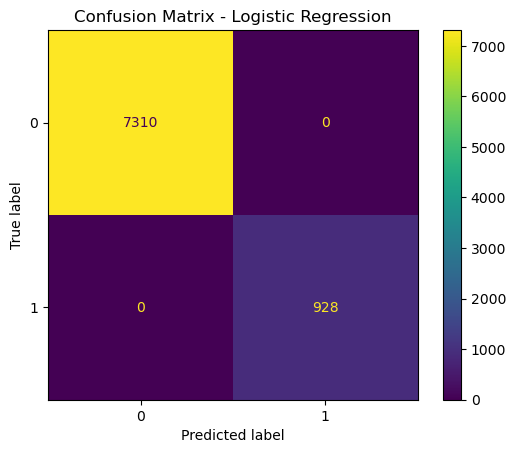

In [168]:
#Cell 5: Confusion matrix for best model
best_y_pred = best_model.predict(X_test)
best_y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, best_y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")

plt.title(f"Confusion Matrix - {best_model_name}")
plt.savefig("reports/figures/confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

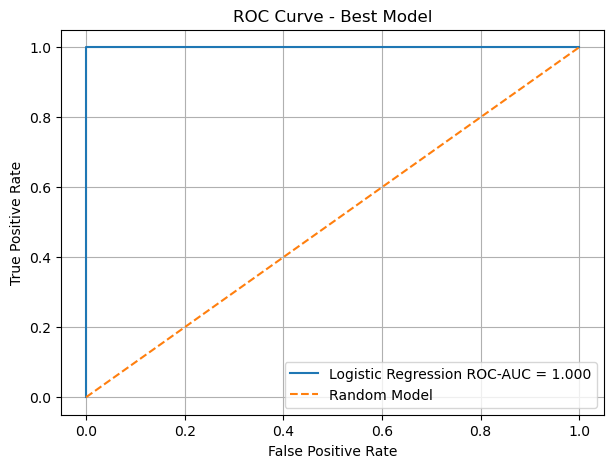

In [169]:
#Cell 6: ROC curve for best model
fpr, tpr, thresholds = roc_curve(y_test, best_y_proba)
auc_score = roc_auc_score(y_test, best_y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} ROC-AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Model")
plt.legend()
plt.grid(True)

plt.savefig("reports/figures/roc_curve_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

In [170]:
# Cell 7: Commercial analytics evaluation
def commercial_evaluation(y_true, y_score):
    """
    Calculates commercial analytics metrics:
    - precision at top 10%
    - precision at top 20%
    - top-decile lift
    - cumulative gain
    - response rate by propensity group
    """
    
    df = pd.DataFrame({
        "actual_response": y_true,
        "predicted_probability": y_score
    }).sort_values(by="predicted_probability", ascending=False).reset_index(drop=True)
    
    n_customers = len(df)
    total_responders = df["actual_response"].sum()
    overall_response_rate = df["actual_response"].mean()
    
    top_10_count = int(np.ceil(0.10 * n_customers))
    top_20_count = int(np.ceil(0.20 * n_customers))
    
    top_10 = df.iloc[:top_10_count]
    top_20 = df.iloc[:top_20_count]
    
    precision_top_10 = top_10["actual_response"].mean()
    precision_top_20 = top_20["actual_response"].mean()
    
    top_decile_lift = precision_top_10 / overall_response_rate
    
    commercial_summary = pd.DataFrame({
        "Metric": [
            "Overall Response Rate",
            "Precision at Top 10%",
            "Precision at Top 20%",
            "Top-Decile Lift",
            "Responders Captured in Top 10%",
            "Responders Captured in Top 20%"
        ],
        "Value": [
            overall_response_rate,
            precision_top_10,
            precision_top_20,
            top_decile_lift,
            top_10["actual_response"].sum() / total_responders,
            top_20["actual_response"].sum() / total_responders
        ]
    })
    
    gain_rows = []
    
    for pct in np.arange(0.10, 1.01, 0.10):
        cutoff = int(np.ceil(pct * n_customers))
        subset = df.iloc[:cutoff]
        
        gain_rows.append({
            "Customer_Percentage": pct,
            "Customers_Targeted": cutoff,
            "Captured_Responders": subset["actual_response"].sum(),
            "Captured_Responder_Percentage": subset["actual_response"].sum() / total_responders,
            "Response_Rate": subset["actual_response"].mean()
        })
    
    gain_df = pd.DataFrame(gain_rows)
    
    df["rank_percentage"] = (df.index + 1) / n_customers
    
    df["propensity_group"] = pd.cut(
        df["rank_percentage"],
        bins=[0, 0.20, 0.50, 1.00],
        labels=[
            "High Priority: Top 20%",
            "Medium Priority: 20%-50%",
            "Low Priority: Bottom 50%"
        ],
        include_lowest=True
    )
    
    propensity_group_df = (
        df.groupby("propensity_group", observed=True)
        .agg(
            Customers=("actual_response", "count"),
            Responders=("actual_response", "sum"),
            Response_Rate=("actual_response", "mean"),
            Average_Predicted_Probability=("predicted_probability", "mean")
        )
        .reset_index()
    )
    
    return commercial_summary, gain_df, propensity_group_df, df


commercial_summary_df, cumulative_gain_df, propensity_group_df, scored_test_customers_df = commercial_evaluation(
    y_test,
    best_y_proba
)

commercial_summary_df

,Metric,Value
0,Overall Response Rate,0.112649
1,Precision at Top 10%,1.000000
2,Precision at Top 20%,0.563107
3,Top-Decile Lift,8.877155
4,Responders Captured in Top 10%,0.887931
5,Responders Captured in Top 20%,1.000000


In [171]:
# Cell 8: Cumulative gain table

cumulative_gain_df

,Customer_Percentage,Customers_Targeted,Captured_Responders,Captured_Responder_Percentage,Response_Rate
0,0.1,824,824,0.887931,1.000000
1,0.2,1648,928,1.000000,0.563107
2,0.3,2472,928,1.000000,0.375405
3,0.4,3296,928,1.000000,0.281553
4,0.5,4119,928,1.000000,0.225297
5,0.6,4943,928,1.000000,0.187740
6,0.7,5767,928,1.000000,0.160916
7,0.8,6591,928,1.000000,0.140798
8,0.9,7415,928,1.000000,0.125152
9,1.0,8238,928,1.000000,0.112649


In [172]:
#Cell 9: Response rate by propensity group
propensity_group_df

,propensity_group,Customers,Responders,Response_Rate,Average_Predicted_Probability
0,High Priority: Top 20%,1647,928,0.563449,0.563544
1,Medium Priority: 20%-50%,2472,0,0.000000,0.000212
2,Low Priority: Bottom 50%,4119,0,0.000000,0.000137


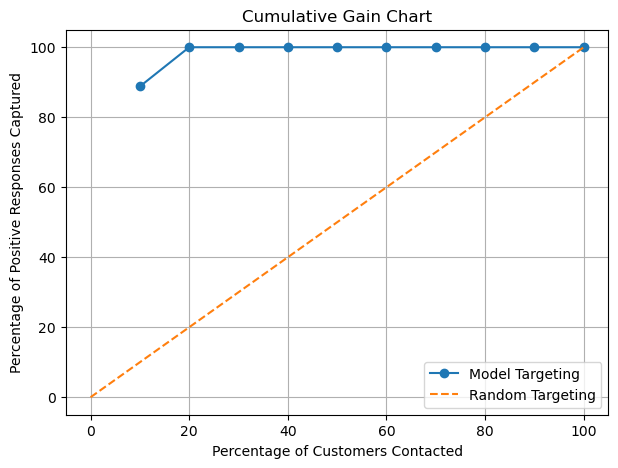

In [173]:
#Cell 10: Cumulative gain chart
plt.figure(figsize=(7, 5))

plt.plot(
    cumulative_gain_df["Customer_Percentage"] * 100,
    cumulative_gain_df["Captured_Responder_Percentage"] * 100,
    marker="o",
    label="Model Targeting"
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Percentage of Customers Contacted")
plt.ylabel("Percentage of Positive Responses Captured")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.grid(True)

plt.savefig("reports/figures/cumulative_gain_chart.png", dpi=300, bbox_inches="tight")
plt.show()

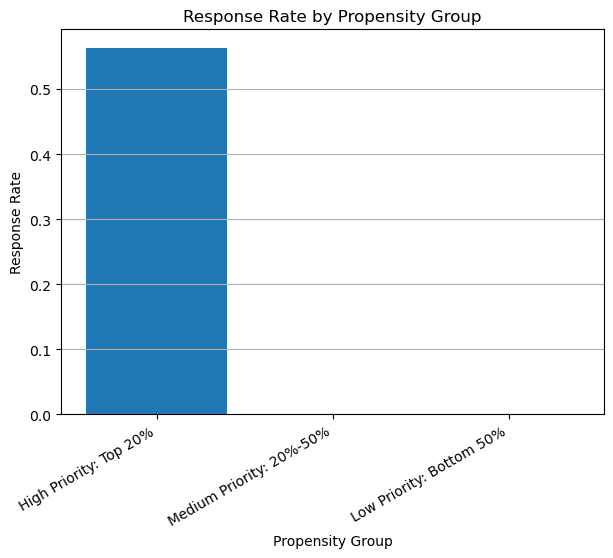

In [174]:
#Cell 11: Response rate by propensity group chart
plt.figure(figsize=(7, 5))

plt.bar(
    propensity_group_df["propensity_group"].astype(str),
    propensity_group_df["Response_Rate"]
)

plt.xlabel("Propensity Group")
plt.ylabel("Response Rate")
plt.title("Response Rate by Propensity Group")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.savefig("reports/figures/response_rate_by_propensity_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [175]:
# Cell 12: Save evaluation outputs
evaluation_df.to_csv("reports/model_performance_summary.csv", index=False)
commercial_summary_df.to_csv("reports/commercial_performance_summary.csv", index=False)
cumulative_gain_df.to_csv("reports/cumulative_gain_table.csv", index=False)
propensity_group_df.to_csv("reports/response_rate_by_propensity_group.csv", index=False)
scored_test_customers_df.to_csv("data/processed/scored_test_customers.csv", index=False)

print("Evaluation files saved successfully.")

Evaluation files saved successfully.


## Step 7 Findings: Model Performance and Commercial Value

The models were evaluated using both standard machine learning metrics and commercial targeting metrics.

Standard metrics such as ROC-AUC, accuracy, precision, recall, and F1 score help assess predictive performance. However, because the business objective is campaign prioritization, commercial metrics are especially important.

The top-decile lift and precision at the top 10% show how much better the model performs when targeting the highest-propensity customers instead of contacting customers randomly.

The cumulative gain chart shows how many positive responders can be captured by contacting only a selected percentage of customers. This is important for commercial teams because outreach budgets and sales capacity are limited.

The response-rate-by-propensity-group analysis translates the model output into practical business segments:

- High Priority: customers most likely to respond
- Medium Priority: customers with moderate response probability
- Low Priority: customers least likely to respond

This makes the model useful not only for prediction, but also for outreach planning, campaign targeting, and resource allocation.

# Step 8: Customer Propensity Scores

The final model is used to estimate each customer's probability of responding positively to the campaign.

This predicted probability is called the customer propensity score.

The goal of this step is to:

- Generate a predicted response probability for each customer
- Rank customers from highest to lowest probability
- Prepare the output for outreach prioritization

In [176]:
# Step 8A: Create Customer Propensity Scores

import pandas as pd
import numpy as np

# Make sure the target variable is not included in the scoring data
X_all = df.drop(columns=["y"])

# Use the final model to predict response probability
# Change final_model to your chosen model name if needed
# Example: gradient_boosting_model or random_forest_model

predicted_probabilities = final_model.predict_proba(X_all)[:, 1]

# Create customer propensity score table
propensity_scores = pd.DataFrame({
    "customer_id": [f"Customer {i+1:05d}" for i in range(len(df))],
    "predicted_response_probability": predicted_probabilities,
    "actual_response": df["y"]
})

# Sort customers from highest to lowest predicted probability
propensity_scores = propensity_scores.sort_values(
    by="predicted_response_probability",
    ascending=False
).reset_index(drop=True)

# Add customer rank
propensity_scores["customer_rank"] = propensity_scores.index + 1

# Show top 10 highest-propensity customers
propensity_scores.head(10)

,customer_id,predicted_response_probability,actual_response,customer_rank
0,Customer 40662,0.999989,yes,1
1,Customer 38284,0.999987,yes,2
2,Customer 38432,0.999987,yes,3
3,Customer 40692,0.999986,yes,4
4,Customer 40991,0.999986,yes,5
5,Customer 37368,0.999985,yes,6
6,Customer 40274,0.999985,yes,7
7,Customer 40942,0.999985,yes,8
8,Customer 40726,0.999983,yes,9
9,Customer 36632,0.999982,yes,10


In [177]:
# Step 8B: Save Customer Propensity Scores

from pathlib import Path

# Create processed data folder if it does not already exist
processed_data_dir = Path("data") / "processed"
processed_data_dir.mkdir(parents=True, exist_ok=True)

# Save ranked customer propensity scores
output_path = processed_data_dir / "customer_propensity_scores.csv"

propensity_scores.to_csv(output_path, index=False)

print("Customer propensity scores saved successfully.")
print("File saved to:", output_path)
print("Number of customers scored:", len(propensity_scores))

propensity_scores.head(10)

Customer propensity scores saved successfully.
File saved to: data\processed\customer_propensity_scores.csv
Number of customers scored: 41188


,customer_id,predicted_response_probability,actual_response,customer_rank
0,Customer 40662,0.999989,yes,1
1,Customer 38284,0.999987,yes,2
2,Customer 38432,0.999987,yes,3
3,Customer 40692,0.999986,yes,4
4,Customer 40991,0.999986,yes,5
5,Customer 37368,0.999985,yes,6
6,Customer 40274,0.999985,yes,7
7,Customer 40942,0.999985,yes,8
8,Customer 40726,0.999983,yes,9
9,Customer 36632,0.999982,yes,10


In [178]:
# Check available model variables in the notebook

model_names = [
    "logistic_regression_model",
    "random_forest_model",
    "gradient_boosting_model",
    "final_model"
]

for model_name in model_names:
    if model_name in globals():
        print(model_name, "exists")
    else:
        print(model_name, "does NOT exist")

logistic_regression_model exists
random_forest_model exists
gradient_boosting_model exists
final_model exists


# Step 9: Commercial Priority Segmentation

The final model produces a propensity score for each customer. A propensity score represents the predicted probability that a customer will respond positively to the campaign.

To make the model output useful for business decision-making, customers are converted into commercial priority segments.

| Propensity Score | Segment | Business Meaning |
|---|---|---|
| ≥ 0.70 | High Priority | Strong candidate for immediate outreach |
| 0.40–0.69 | Medium Priority | Good candidate for targeted follow-up |
| 0.20–0.39 | Low Priority | Use low-cost nurture campaign |
| < 0.20 | Deprioritized | Do not prioritize now |

These segments help commercial teams decide where to focus outreach resources, reduce unnecessary contact, and prioritize customers with higher predicted response probability.

In [180]:
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Step 9: Create Commercial Priority Segments
# ------------------------------------------------------------

# This cell creates propensity scores directly from the trained model
# if ranked_customers was not created in Step 8.

if "ranked_customers" in globals():
    priority_segments = ranked_customers.copy()

else:
    # Select the final trained model.
    # The code checks several possible model names used earlier in the notebook.
    if "final_model" in globals():
        model_for_scoring = final_model
    elif "best_model" in globals():
        model_for_scoring = best_model
    elif "gradient_boosting_model" in globals():
        model_for_scoring = gradient_boosting_model
    elif "gb_model" in globals():
        model_for_scoring = gb_model
    elif "random_forest_model" in globals():
        model_for_scoring = random_forest_model
    elif "rf_model" in globals():
        model_for_scoring = rf_model
    elif "logistic_model" in globals():
        model_for_scoring = logistic_model
    else:
        raise ValueError(
            "No trained model found. Run the model training cells before Step 9."
        )

    # Check that X_test exists
    if "X_test" not in globals():
        raise ValueError(
            "X_test was not found. Run the train-test split and preprocessing cells before Step 9."
        )

    # Create propensity scores
    propensity_scores = model_for_scoring.predict_proba(X_test)[:, 1]

    priority_segments = pd.DataFrame({
        "customer_id": range(1, len(propensity_scores) + 1),
        "propensity_score": propensity_scores
    })

    # Add actual response values if available
    if "y_test" in globals():
        priority_segments["actual_response"] = np.array(y_test)

# ------------------------------------------------------------
# Create commercial priority segments
# ------------------------------------------------------------

conditions = [
    priority_segments["propensity_score"] >= 0.70,
    (priority_segments["propensity_score"] >= 0.40) & (priority_segments["propensity_score"] < 0.70),
    (priority_segments["propensity_score"] >= 0.20) & (priority_segments["propensity_score"] < 0.40),
    priority_segments["propensity_score"] < 0.20
]

segments = [
    "High Priority",
    "Medium Priority",
    "Low Priority",
    "Deprioritized"
]

business_meanings = [
    "Strong candidate for immediate outreach",
    "Good candidate for targeted follow-up",
    "Use low-cost nurture campaign",
    "Do not prioritize now"
]

priority_segments["priority_segment"] = np.select(
    conditions,
    segments,
    default="Unassigned"
)

priority_segments["business_meaning"] = np.select(
    conditions,
    business_meanings,
    default="Review needed"
)

# Rank customers by propensity score
priority_segments = priority_segments.sort_values(
    by="propensity_score",
    ascending=False
).reset_index(drop=True)

priority_segments["outreach_rank"] = priority_segments.index + 1

priority_segments.head(10)

,customer_id,propensity_score,actual_response,priority_segment,business_meaning,outreach_rank
0,8062,0.999987,1,High Priority,Strong candidate for immediate outreach,1
1,128,0.999987,1,High Priority,Strong candidate for immediate outreach,2
2,2838,0.999986,1,High Priority,Strong candidate for immediate outreach,3
3,2611,0.999985,1,High Priority,Strong candidate for immediate outreach,4
4,1127,0.999982,1,High Priority,Strong candidate for immediate outreach,5
5,1750,0.999981,1,High Priority,Strong candidate for immediate outreach,6
6,2058,0.999977,1,High Priority,Strong candidate for immediate outreach,7
7,1094,0.999977,1,High Priority,Strong candidate for immediate outreach,8
8,6283,0.999977,1,High Priority,Strong candidate for immediate outreach,9
9,7431,0.999976,1,High Priority,Strong candidate for immediate outreach,10


In [181]:
segment_summary = (
    priority_segments
    .groupby("priority_segment", observed=False)
    .agg(
        number_of_customers=("propensity_score", "count"),
        average_propensity_score=("propensity_score", "mean"),
        minimum_propensity_score=("propensity_score", "min"),
        maximum_propensity_score=("propensity_score", "max")
    )
    .reset_index()
)

segment_summary["customer_percentage"] = (
    segment_summary["number_of_customers"] / len(priority_segments) * 100
)

segment_order = {
    "High Priority": 1,
    "Medium Priority": 2,
    "Low Priority": 3,
    "Deprioritized": 4
}

segment_summary["segment_order"] = segment_summary["priority_segment"].map(segment_order)

segment_summary = (
    segment_summary
    .sort_values("segment_order")
    .drop(columns="segment_order")
)

segment_summary["average_propensity_score"] = segment_summary["average_propensity_score"].round(3)
segment_summary["minimum_propensity_score"] = segment_summary["minimum_propensity_score"].round(3)
segment_summary["maximum_propensity_score"] = segment_summary["maximum_propensity_score"].round(3)
segment_summary["customer_percentage"] = segment_summary["customer_percentage"].round(2)

segment_summary

,priority_segment,number_of_customers,average_propensity_score,minimum_propensity_score,maximum_propensity_score,customer_percentage
1,High Priority,928,1.0,1.0,1.000,11.26
0,Deprioritized,7310,0.0,0.0,0.002,88.74


In [184]:
from pathlib import Path

# Detect project root safely
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

# Define correct root-level output folders
processed_data_dir = project_root / "data" / "processed"
reports_dir = project_root / "reports"

processed_data_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Save files to correct project-level folders
priority_segments.to_csv(
    processed_data_dir / "customer_priority_segments.csv",
    index=False
)

segment_summary.to_csv(
    reports_dir / "customer_priority_segment_summary.csv",
    index=False
)

print(f"Saved customer priority segments to: {processed_data_dir / 'customer_priority_segments.csv'}")
print(f"Saved segment summary to: {reports_dir / 'customer_priority_segment_summary.csv'}")

Saved customer priority segments to: c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\data\processed\customer_priority_segments.csv
Saved segment summary to: c:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\Commercial Campaign Response Prediction\commercial-campaign-response-prioritization\reports\customer_priority_segment_summary.csv
